# Hybrid Stacking XAU/USD — Visualization Pipeline

Notebook chạy full pipeline + biểu diễn matplotlib chi tiết.

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
)

from hybrid_stacking.acceleration import configure_accelerator
from hybrid_stacking.backtest import (
    backtest_signals,
    cost_adjusted_returns,
    equity_curve,
)
from hybrid_stacking.config import (
    CV_SPLITS,
    DATA_DIR,
    EMBARGO_PCT,
    FRACTIONAL_D,
    MIN_OOF_F1,
    PURGE_PCT,
    RANDOM_STATE,
    REPORT_DIR,
    PipelineConfig,
    TradingCosts,
)
from hybrid_stacking.data import parquet_files
from hybrid_stacking.dataset import (
    build_dataset,
    feature_columns,
    train_test_time_split,
)
from hybrid_stacking.features import (
    add_technical_features,
    fractional_diff,
)
from hybrid_stacking.labeling import triple_barrier_labels
from hybrid_stacking.models import HybridStackingSignalClassifier
from hybrid_stacking.validation import PurgedEmbargoTimeSeriesSplit

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})

PALETTE = {1: "#2ca02c", 0: "#7f7f7f", -1: "#d62728"}
LABEL_NAMES = {-1: "SHORT", 0: "HOLD", 1: "LONG"}

accelerator = configure_accelerator(RANDOM_STATE)
print(f"Accelerate device: {accelerator.device} | processes: {accelerator.num_processes}")

Accelerate device: cpu | processes: 1


In [2]:
MONTHS = 36
config = PipelineConfig(months=MONTHS)

files = parquet_files(DATA_DIR, config.months)
print(f"Data dir: {DATA_DIR.resolve()}")
print(f"Parquet files: {len(files)}")
print(f"Range: {files[0].stem} → {files[-1].stem}")

Data dir: /home/ultimatebrok/Downloads/thesis-compact/data/raw/XAUUSD
Parquet files: 36
Range: 2023-05 → 2026-04


## 2. Build Dataset

In [3]:
dataset = build_dataset(config)
train, test = train_test_time_split(dataset, purge_pct=PURGE_PCT)
features = feature_columns(dataset)

print(f"Rows: {len(dataset):,}")
print(f"Train: {len(train):,} | Test: {len(test):,}")
print(f"Features: {len(features)}")
print(f"Fractional d: {dataset.attrs.get('fractional_d', 'n/a')}")


Rows: 17,475
Train: 13,980 | Test: 3,145
Features: 20
Fractional d: 0.4


## 3. Price & Raw Data Visualization

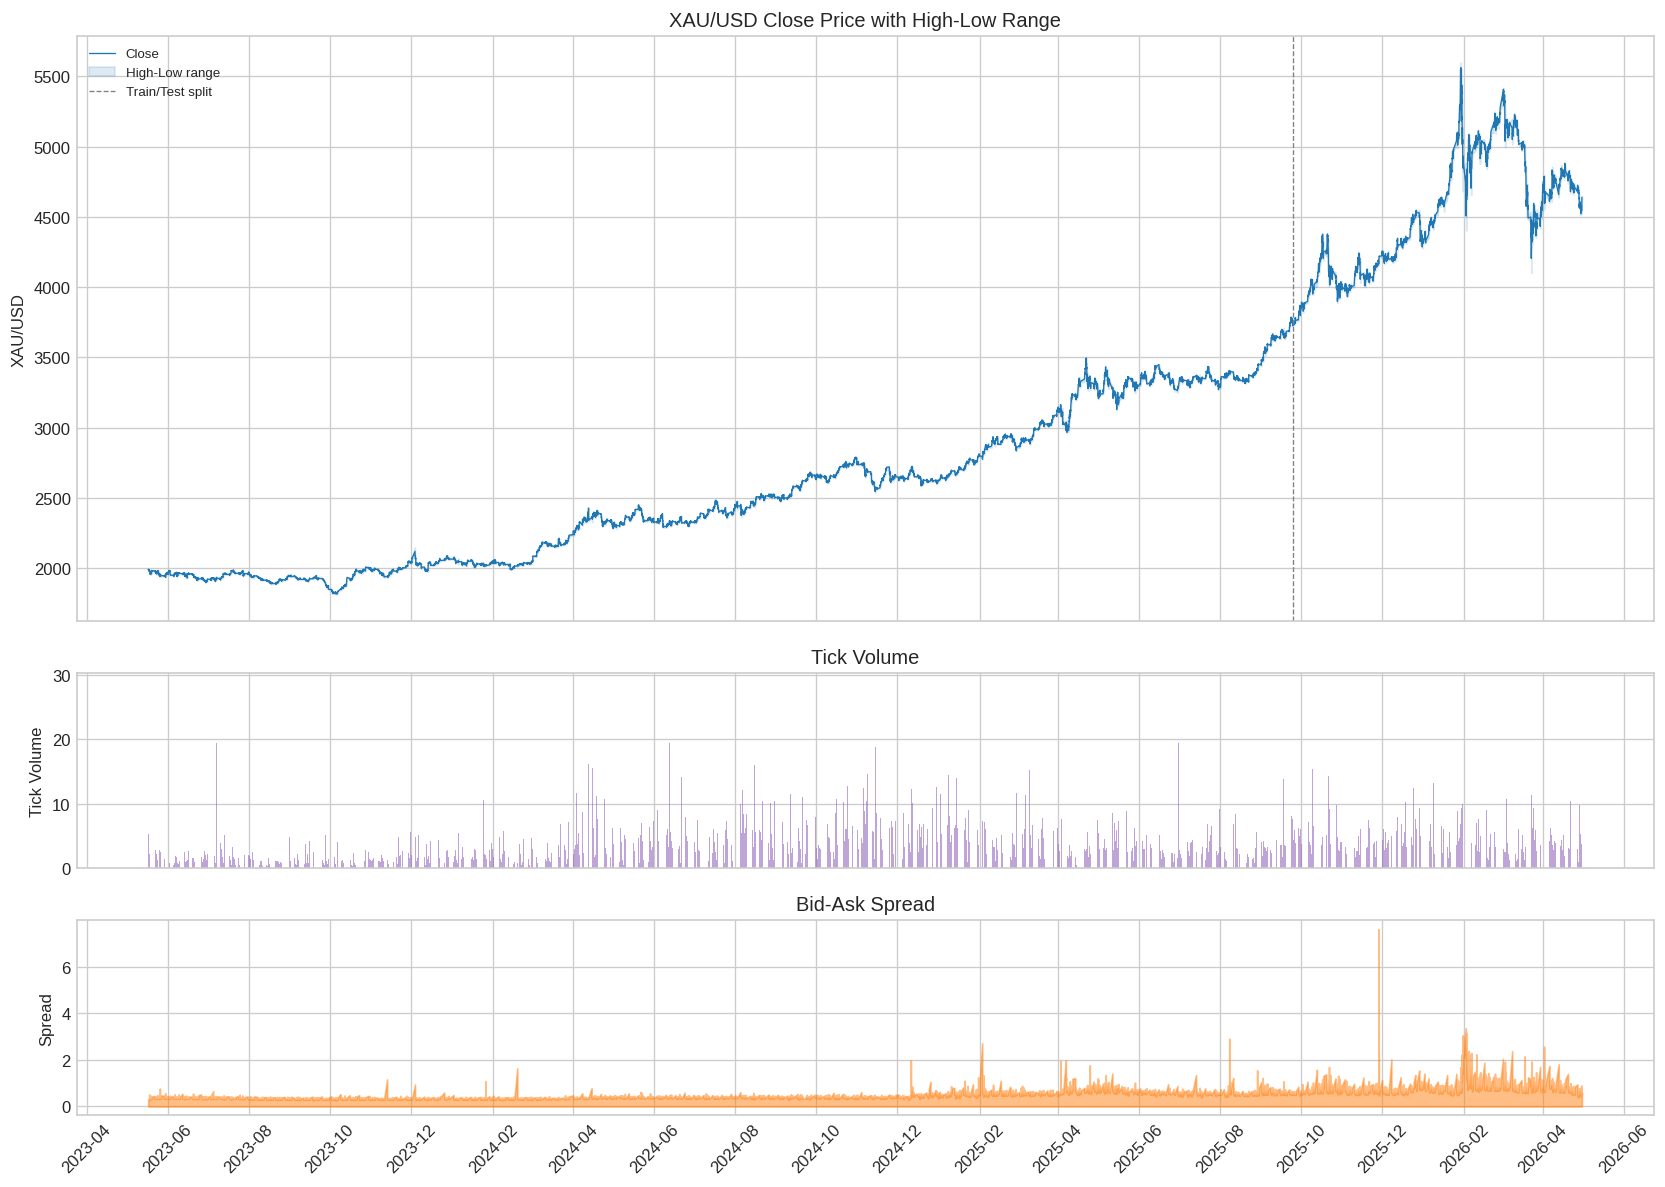

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, height_ratios=[3, 1, 1])

ax_price, ax_vol, ax_spread = axes

ax_price.plot(dataset.index, dataset["close"], color="#1f77b4", linewidth=0.8, label="Close")
ax_price.fill_between(
    dataset.index, dataset["low"], dataset["high"],
    alpha=0.15, color="#1f77b4", label="High-Low range"
)
ax_price.axvline(train.index[-1], color="gray", linestyle="--", linewidth=0.8, label="Train/Test split")
ax_price.set_ylabel("XAU/USD")
ax_price.legend(loc="upper left", fontsize=8)
ax_price.set_title("XAU/USD Close Price with High-Low Range")

ax_vol.bar(dataset.index, dataset["volume"], width=0.03, color="#9467bd", alpha=0.6)
ax_vol.set_ylabel("Tick Volume")
ax_vol.set_title("Tick Volume")

ax_spread.fill_between(dataset.index, 0, dataset["spread"], color="#ff7f0e", alpha=0.5)
ax_spread.set_ylabel("Spread")
ax_spread.set_title("Bid-Ask Spread")
ax_spread.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax_spread.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)

fig.tight_layout()
plt.show()

## 4. Label Distribution Visualization

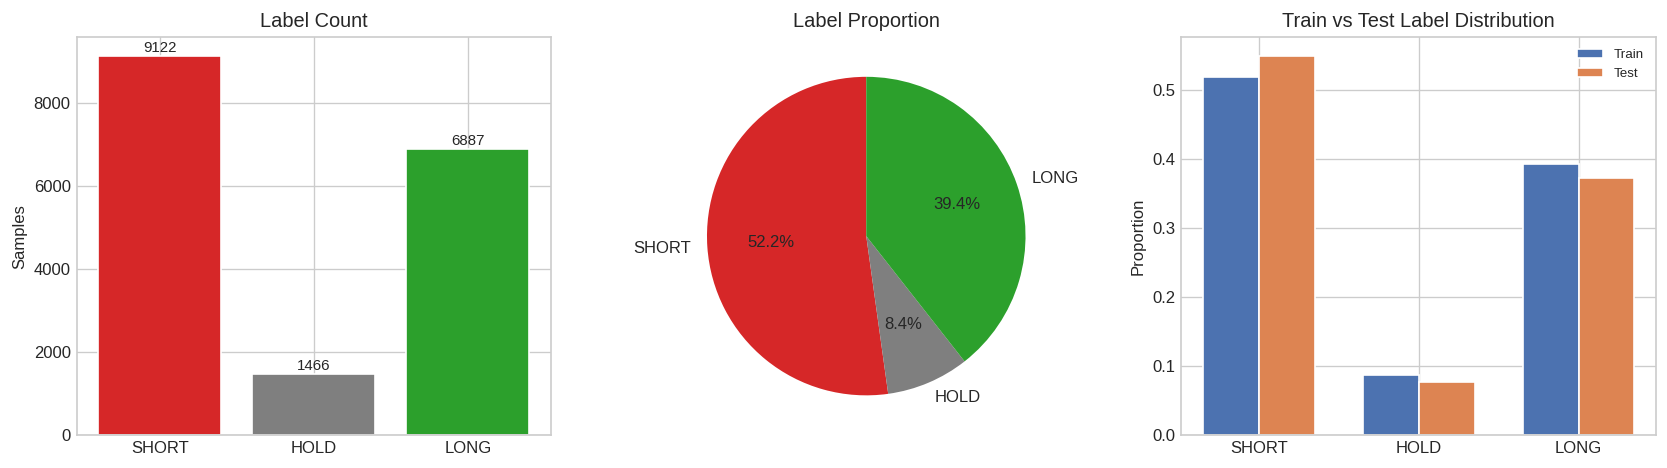

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

label_counts = dataset["label"].value_counts().sort_index()
colors = [PALETTE[k] for k in label_counts.index]

axes[0].bar(
    [LABEL_NAMES[k] for k in label_counts.index],
    label_counts.values, color=colors, edgecolor="white"
)
axes[0].set_title("Label Count")
axes[0].set_ylabel("Samples")

for i, (k, v) in enumerate(label_counts.items()):
    axes[0].text(i, v + max(label_counts) * 0.01, str(v), ha="center", fontsize=9)

label_pct = dataset["label"].value_counts(normalize=True).sort_index() * 100
axes[1].pie(
    label_pct.values, labels=[LABEL_NAMES[k] for k in label_pct.index],
    colors=colors, autopct="%.1f%%", startangle=90
)
axes[1].set_title("Label Proportion")

train_labels = train["label"].value_counts(normalize=True).sort_index()
test_labels = test["label"].value_counts(normalize=True).sort_index()
x = np.arange(3)
width = 0.35
axes[2].bar(x - width/2, train_labels.values, width, label="Train", color="#4c72b0", edgecolor="white")
axes[2].bar(x + width/2, test_labels.values, width, label="Test", color="#dd8452", edgecolor="white")
axes[2].set_xticks(x)
axes[2].set_xticklabels([LABEL_NAMES[k] for k in train_labels.index])
axes[2].set_title("Train vs Test Label Distribution")
axes[2].set_ylabel("Proportion")
axes[2].legend(fontsize=8)

fig.tight_layout()
plt.show()

## 5. Price with Triple Barrier Labels

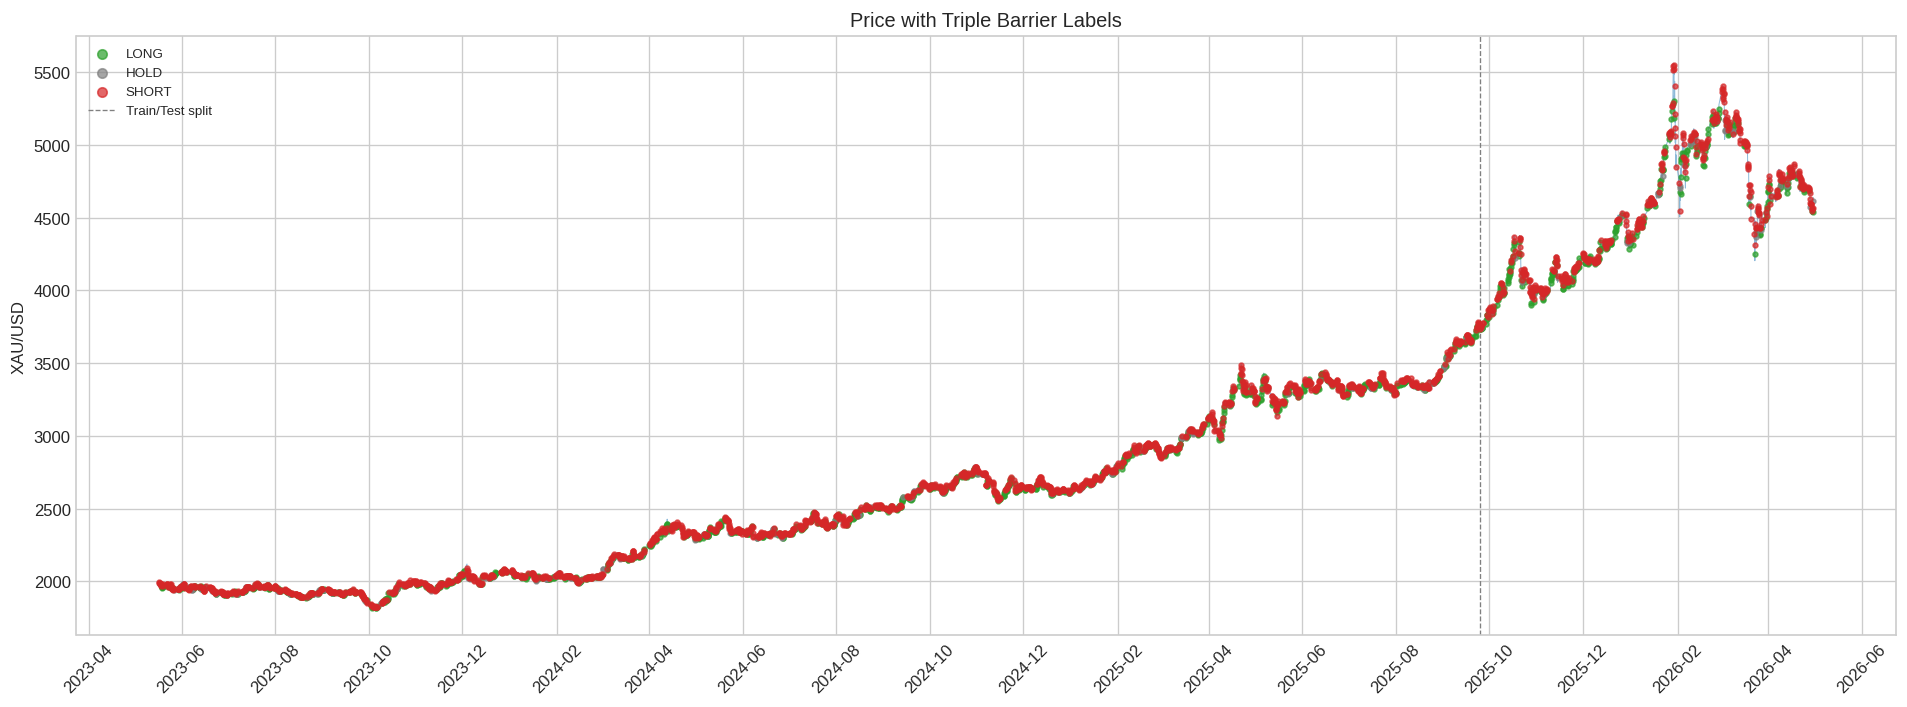

In [6]:
fig, ax = plt.subplots(figsize=(16, 6))

sample = dataset.iloc[::4]
ax.plot(dataset.index, dataset["close"], color="#1f77b4", linewidth=0.6, alpha=0.5)

for label_val, color in PALETTE.items():
    mask = sample["label"] == label_val
    ax.scatter(
        sample.index[mask], sample.loc[mask, "close"],
        c=color, s=8, alpha=0.7, label=LABEL_NAMES[label_val], zorder=3
    )

ax.axvline(train.index[-1], color="gray", linestyle="--", linewidth=0.8, label="Train/Test split")
ax.set_title("Price with Triple Barrier Labels")
ax.set_ylabel("XAU/USD")
ax.legend(loc="upper left", fontsize=8, markerscale=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()

## 6. Feature Engineering Visualization

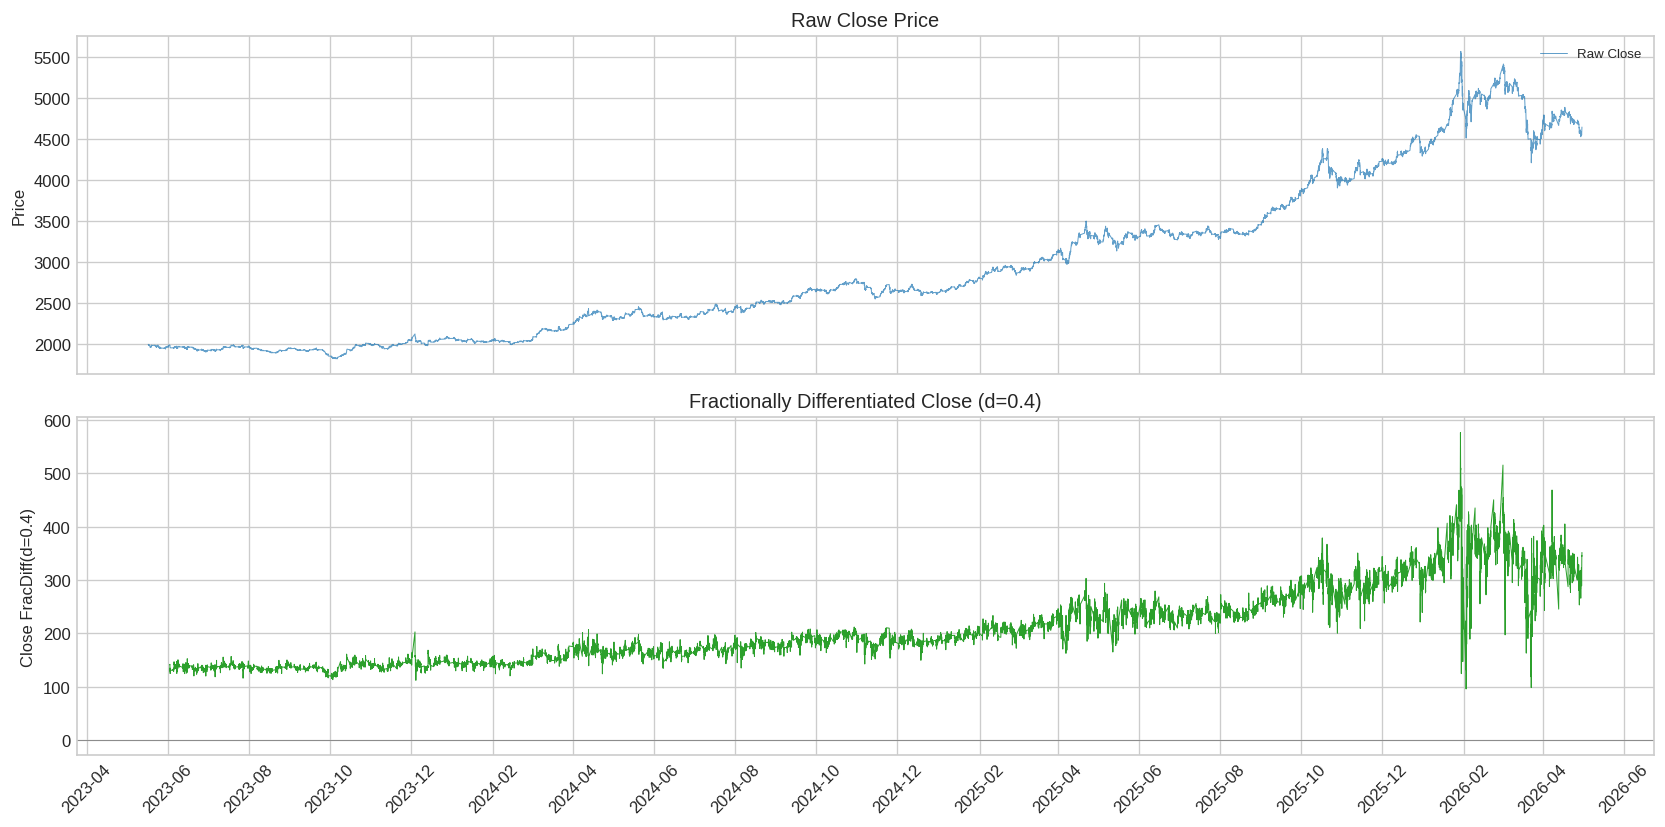

In [7]:
candles = dataset[["close"]].copy()
frac_d = dataset.attrs.get("fractional_d", 0.4)
candles["close_fracdiff"] = fractional_diff(candles["close"], frac_d)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(candles.index, candles["close"], color="#1f77b4", linewidth=0.6, alpha=0.7, label="Raw Close")
axes[0].set_title(f"Raw Close Price")
axes[0].legend(fontsize=8)
axes[0].set_ylabel("Price")

axes[1].plot(candles.index, candles["close_fracdiff"], color="#2ca02c", linewidth=0.6)
axes[1].axhline(0, color="gray", linewidth=0.5)
axes[1].set_title(f"Fractionally Differentiated Close (d={frac_d})")
axes[1].set_ylabel(f"Close FracDiff(d={frac_d})")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)

fig.tight_layout()
plt.show()


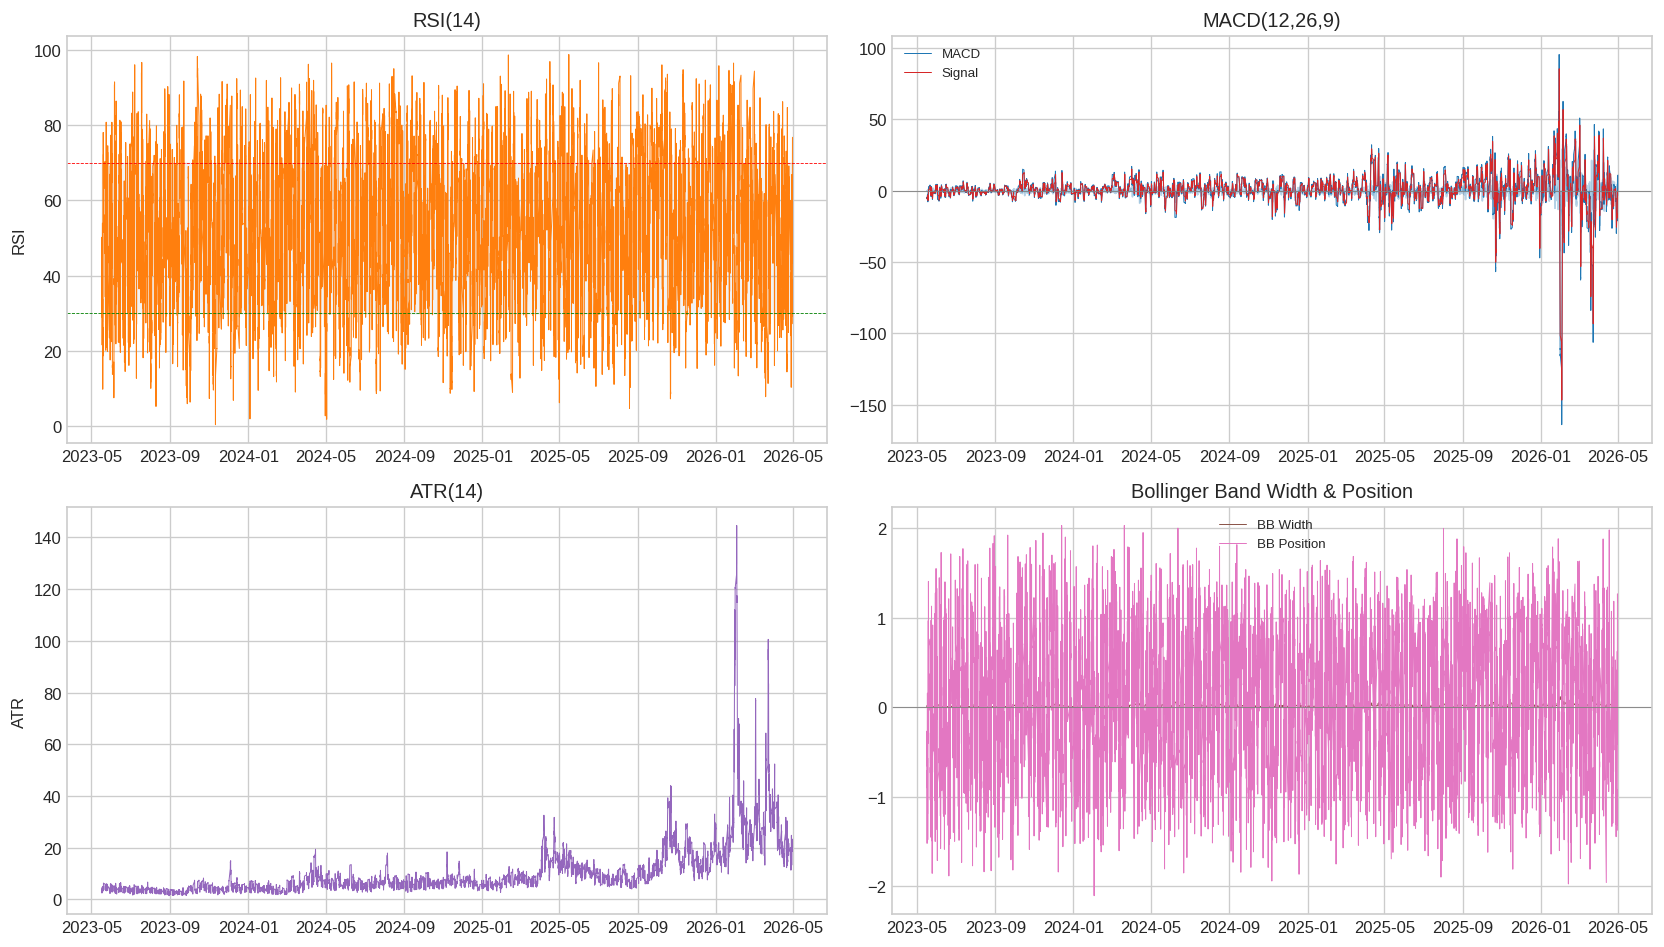

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(dataset.index, dataset["rsi_14"], color="#ff7f0e", linewidth=0.6)
axes[0, 0].axhline(70, color="red", linewidth=0.5, linestyle="--")
axes[0, 0].axhline(30, color="green", linewidth=0.5, linestyle="--")
axes[0, 0].fill_between(dataset.index, 30, 70, alpha=0.1, color="gray")
axes[0, 0].set_title("RSI(14)")
axes[0, 0].set_ylabel("RSI")

axes[0, 1].plot(dataset.index, dataset["macd"], color="#1f77b4", linewidth=0.6, label="MACD")
axes[0, 1].plot(dataset.index, dataset["macd_signal"], color="#d62728", linewidth=0.6, label="Signal")
axes[0, 1].fill_between(
    dataset.index, dataset["macd"] - dataset["macd_signal"],
    alpha=0.3, color="#1f77b4"
)
axes[0, 1].axhline(0, color="gray", linewidth=0.5)
axes[0, 1].set_title("MACD(12,26,9)")
axes[0, 1].legend(fontsize=8)

axes[1, 0].plot(dataset.index, dataset["atr_14"], color="#9467bd", linewidth=0.6)
axes[1, 0].set_title("ATR(14)")
axes[1, 0].set_ylabel("ATR")

axes[1, 1].plot(dataset.index, dataset["bb_width"], color="#8c564b", linewidth=0.6, label="BB Width")
axes[1, 1].plot(dataset.index, dataset["bb_position"], color="#e377c2", linewidth=0.6, label="BB Position")
axes[1, 1].axhline(0, color="gray", linewidth=0.5)
axes[1, 1].set_title("Bollinger Band Width & Position")
axes[1, 1].legend(fontsize=8)

fig.tight_layout()
plt.show()

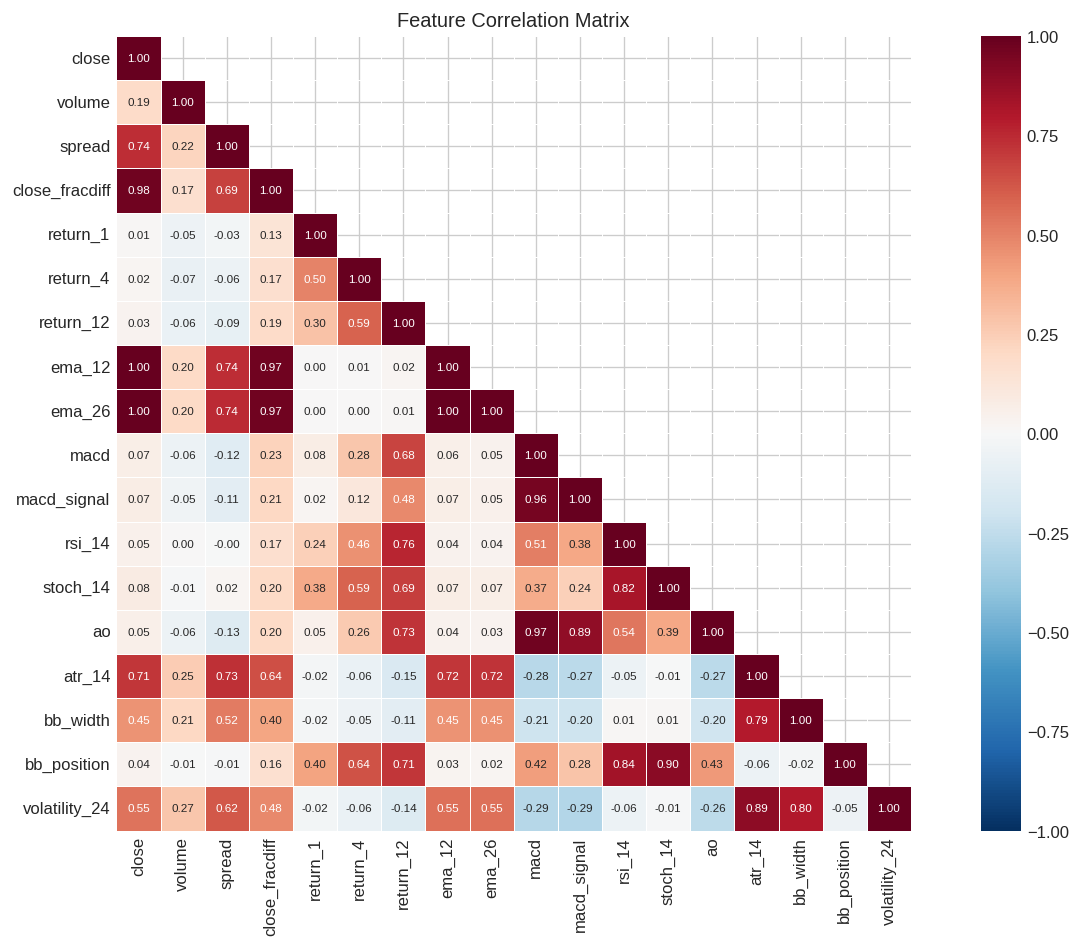

In [9]:
fig, ax = plt.subplots(figsize=(12, 8))

corr_cols = [c for c in features if c in dataset.columns and dataset[c].dtype in ["float64", "int64", "float32"]]
corr = dataset[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.3, ax=ax,
    annot_kws={"size": 7},
)
ax.set_title("Feature Correlation Matrix")
fig.tight_layout()
plt.show()

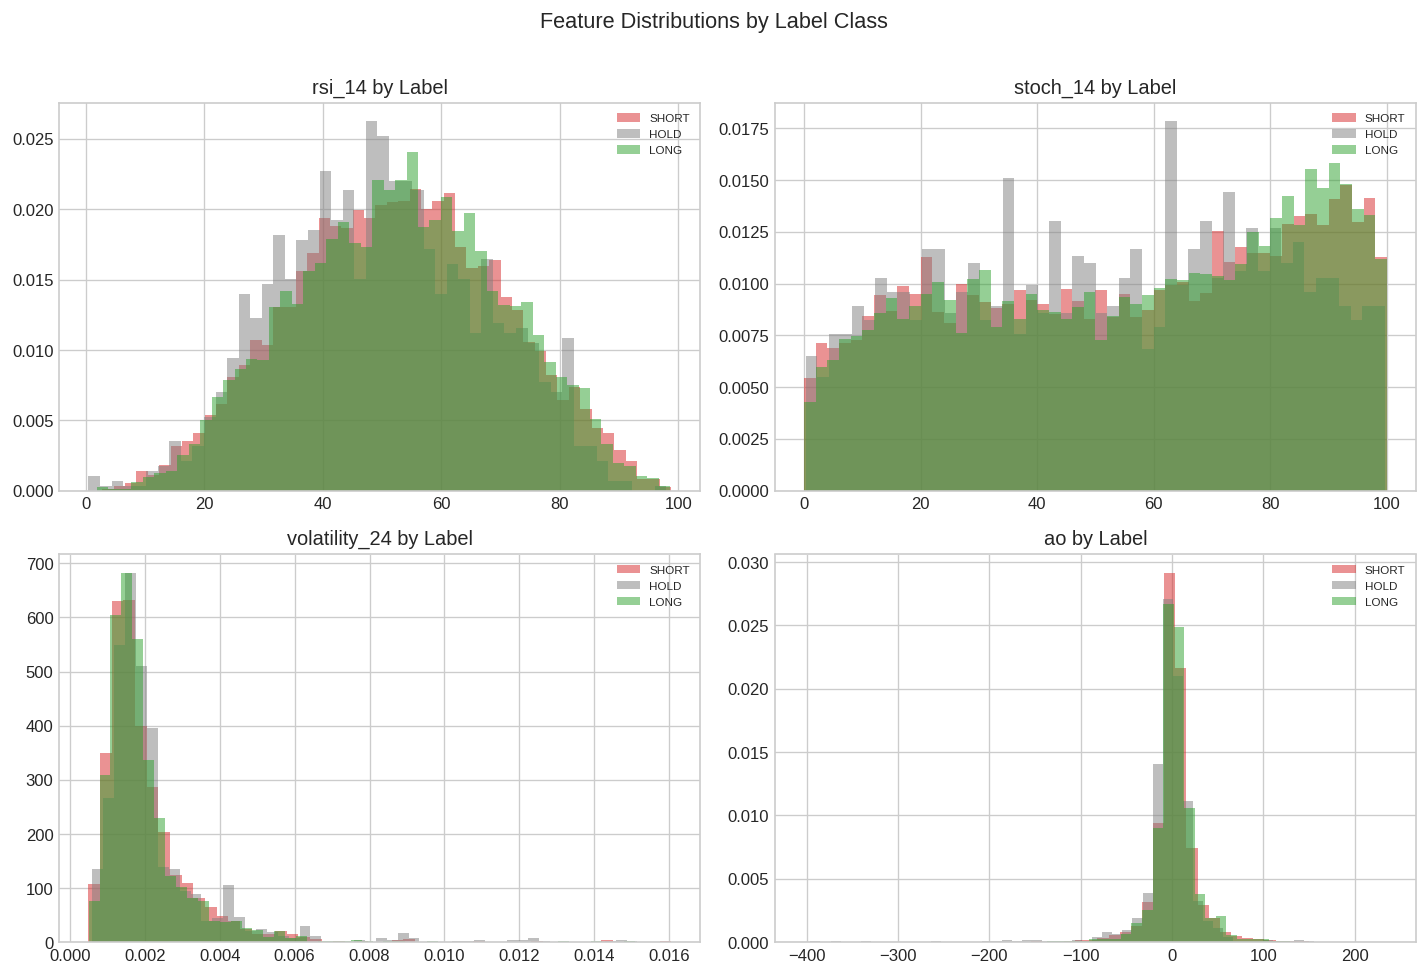

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flat, ["rsi_14", "stoch_14", "volatility_24", "ao"]):
    for label_val in [-1, 0, 1]:
        subset = dataset.loc[dataset["label"] == label_val, col].dropna()
        ax.hist(subset, bins=50, alpha=0.5, color=PALETTE[label_val], label=LABEL_NAMES[label_val], density=True)
    ax.set_title(f"{col} by Label")
    ax.legend(fontsize=7)

fig.suptitle("Feature Distributions by Label Class", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## 7. Purged Embargo CV Splits

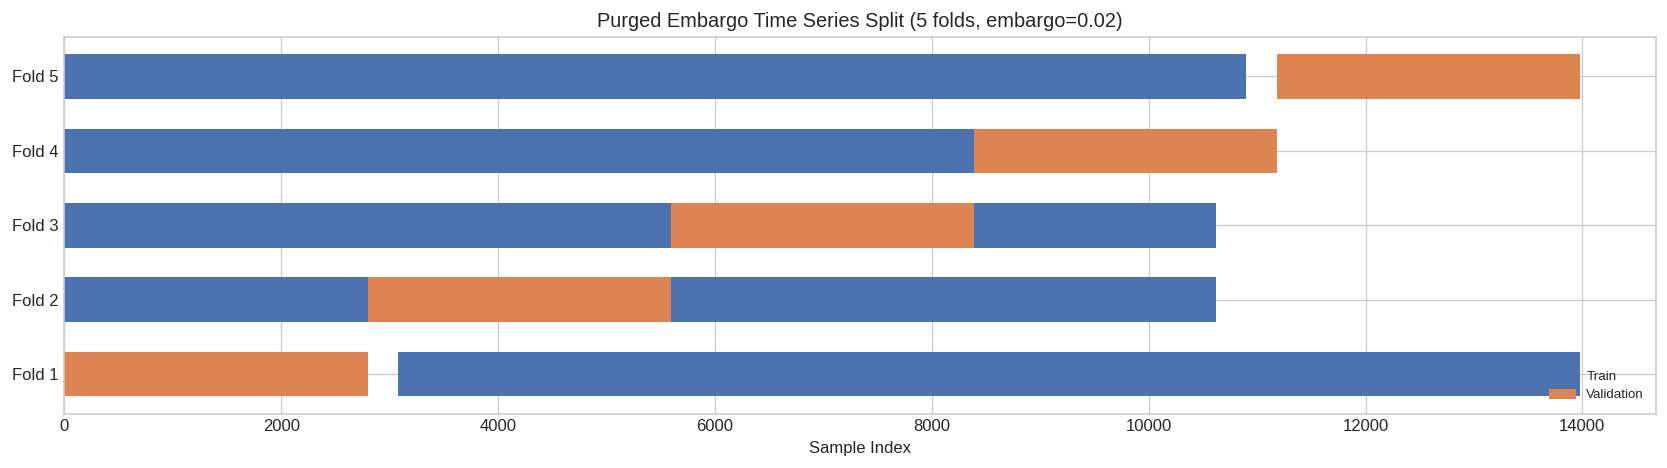

In [11]:
cv = PurgedEmbargoTimeSeriesSplit(CV_SPLITS, EMBARGO_PCT)

fig, ax = plt.subplots(figsize=(14, 4))

for fold, (train_idx, val_idx) in enumerate(cv.split(train[features], train["event_end"])):
    ax.barh(fold, len(train_idx), left=train_idx[0], color="#4c72b0", height=0.6, label="Train" if fold == 0 else "")
    ax.barh(fold, len(val_idx), left=val_idx[0], color="#dd8452", height=0.6, label="Validation" if fold == 0 else "")

ax.set_yticks(range(CV_SPLITS))
ax.set_yticklabels([f"Fold {i+1}" for i in range(CV_SPLITS)])
ax.set_xlabel("Sample Index")
ax.set_title(f"Purged Embargo Time Series Split ({CV_SPLITS} folds, embargo={EMBARGO_PCT})")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
plt.show()

## 8. Train Model

In [12]:
model = HybridStackingSignalClassifier(
    n_splits=CV_SPLITS,
    embargo_pct=EMBARGO_PCT,
    min_oof_f1=MIN_OOF_F1,
    random_state=RANDOM_STATE,
)
model.fit(train[features], train["label"], train["event_end"])
print("Training complete.")

Training complete.


## 9. OOF Scores Visualization

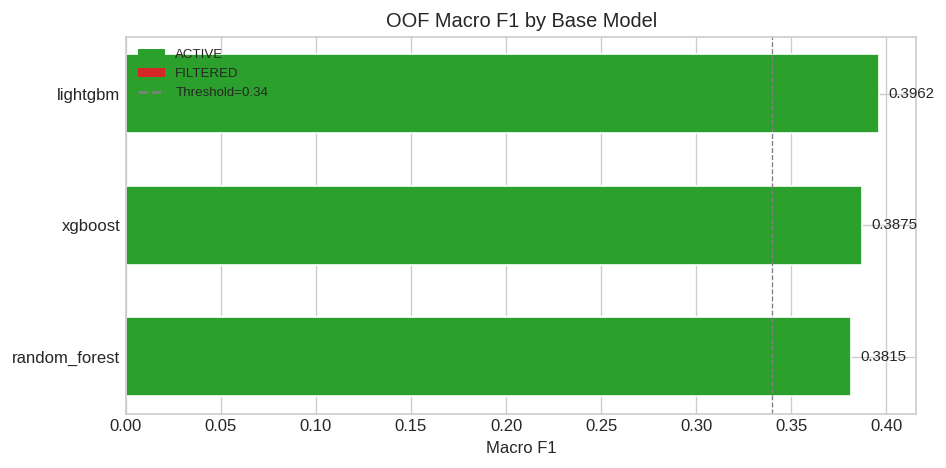

In [13]:
scores = pd.Series(model.oof_scores_).sort_values()
colors = ["#2ca02c" if n in model.active_model_names_ else "#d62728" for n in scores.index]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(scores.index, scores.values, color=colors, edgecolor="white", height=0.6)
ax.axvline(MIN_OOF_F1, color="gray", linestyle="--", linewidth=0.8, label=f"Min OOF F1 = {MIN_OOF_F1}")

for bar, val in zip(bars, scores.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f"{val:.4f}", va="center", fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2ca02c", label="ACTIVE"),
    Patch(facecolor="#d62728", label="FILTERED"),
]
ax.legend(handles=legend_elements + [plt.Line2D([0], [0], color="gray", linestyle="--", label=f"Threshold={MIN_OOF_F1}")], fontsize=8)
ax.set_title("OOF Macro F1 by Base Model")
ax.set_xlabel("Macro F1")
fig.tight_layout()
plt.show()

## 10. Test Set Evaluation

In [14]:
predictions = model.predict(test[features])
pred_proba = model.predict_proba(test[features])

print(f"Accuracy: {accuracy_score(test['label'], predictions):.4f}")
print(f"F1 macro: {f1_score(test['label'], predictions, average='macro', zero_division=0):.4f}")
print(classification_report(test["label"], predictions, zero_division=0))

Accuracy: 0.3984
F1 macro: 0.3211
              precision    recall  f1-score   support

          -1       0.62      0.19      0.29      1730
           0       0.14      0.20      0.16       241
           1       0.39      0.75      0.51      1174

    accuracy                           0.40      3145
   macro avg       0.38      0.38      0.32      3145
weighted avg       0.50      0.40      0.36      3145



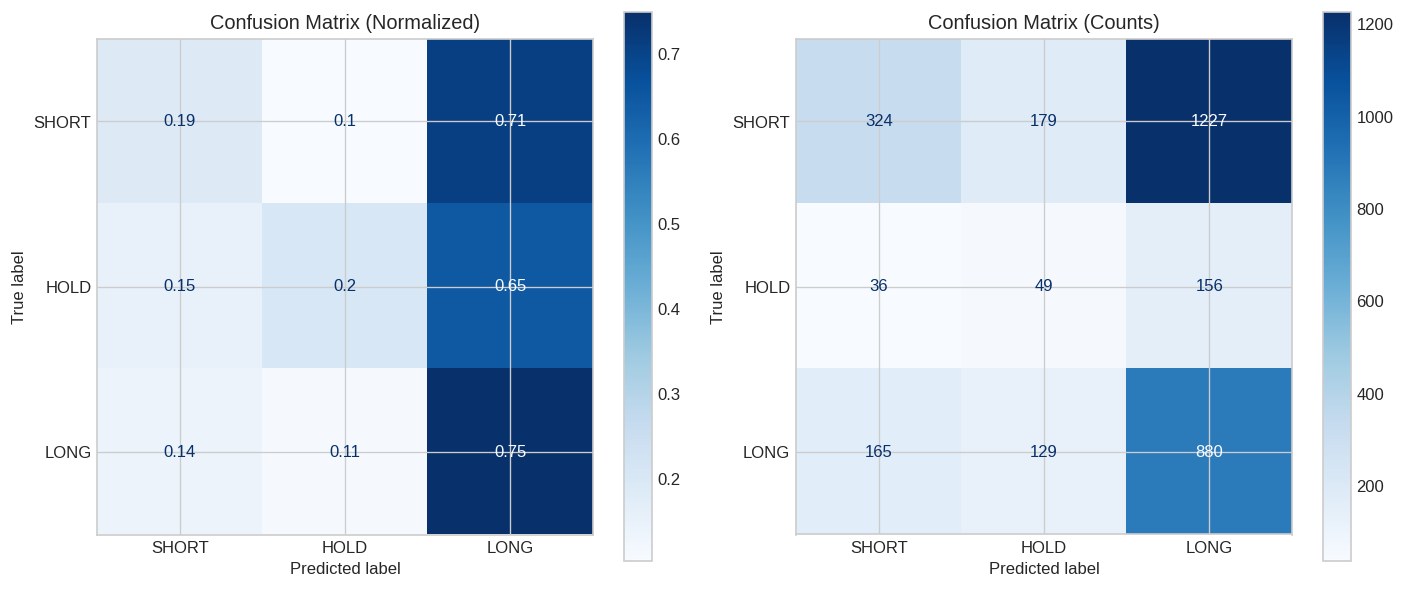

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    test["label"], predictions,
    display_labels=[LABEL_NAMES[k] for k in sorted(LABEL_NAMES)],
    cmap="Blues", ax=axes[0], normalize="true",
)
axes[0].set_title("Confusion Matrix (Normalized)")

ConfusionMatrixDisplay.from_predictions(
    test["label"], predictions,
    display_labels=[LABEL_NAMES[k] for k in sorted(LABEL_NAMES)],
    cmap="Blues", ax=axes[1],
)
axes[1].set_title("Confusion Matrix (Counts)")

fig.tight_layout()
plt.show()

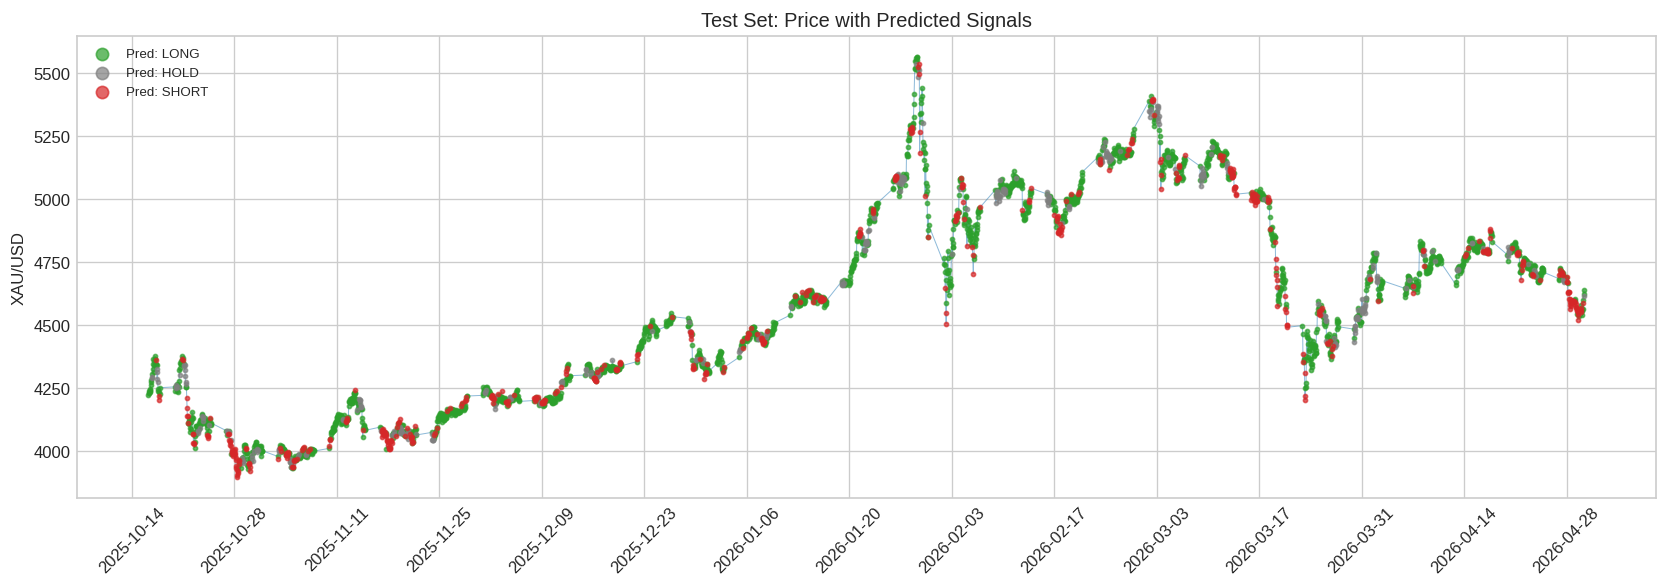

In [16]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(test.index, test["close"], color="#1f77b4", linewidth=0.6, alpha=0.5)

pred_series = pd.Series(predictions, index=test.index)
for label_val, color in PALETTE.items():
    mask = pred_series == label_val
    ax.scatter(
        test.index[mask], test.loc[mask, "close"],
        c=color, s=6, alpha=0.7, label=f"Pred: {LABEL_NAMES[label_val]}", zorder=3
    )

ax.set_title("Test Set: Price with Predicted Signals")
ax.set_ylabel("XAU/USD")
ax.legend(loc="upper left", fontsize=8, markerscale=3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()

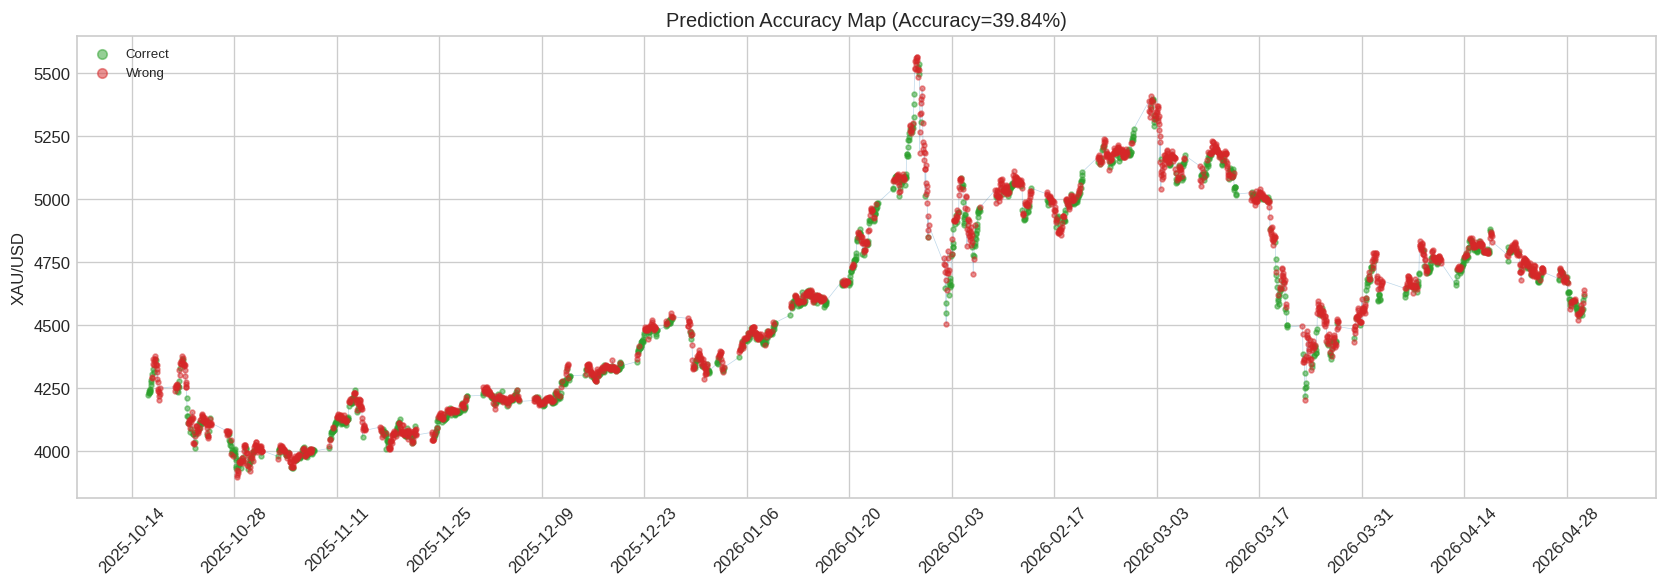

In [17]:
fig, ax = plt.subplots(figsize=(14, 5))

correct = (test["label"].values == predictions)
ax.scatter(test.index[correct], test["close"].iloc[correct], c="#2ca02c", s=8, alpha=0.5, label="Correct", zorder=3)
ax.scatter(test.index[~correct], test["close"].iloc[~correct], c="#d62728", s=8, alpha=0.5, label="Wrong", zorder=3)
ax.plot(test.index, test["close"], color="#1f77b4", linewidth=0.4, alpha=0.3)

acc = accuracy_score(test["label"], predictions)
ax.set_title(f"Prediction Accuracy Map (Accuracy={acc:.2%})")
ax.set_ylabel("XAU/USD")
ax.legend(loc="upper left", fontsize=8, markerscale=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()

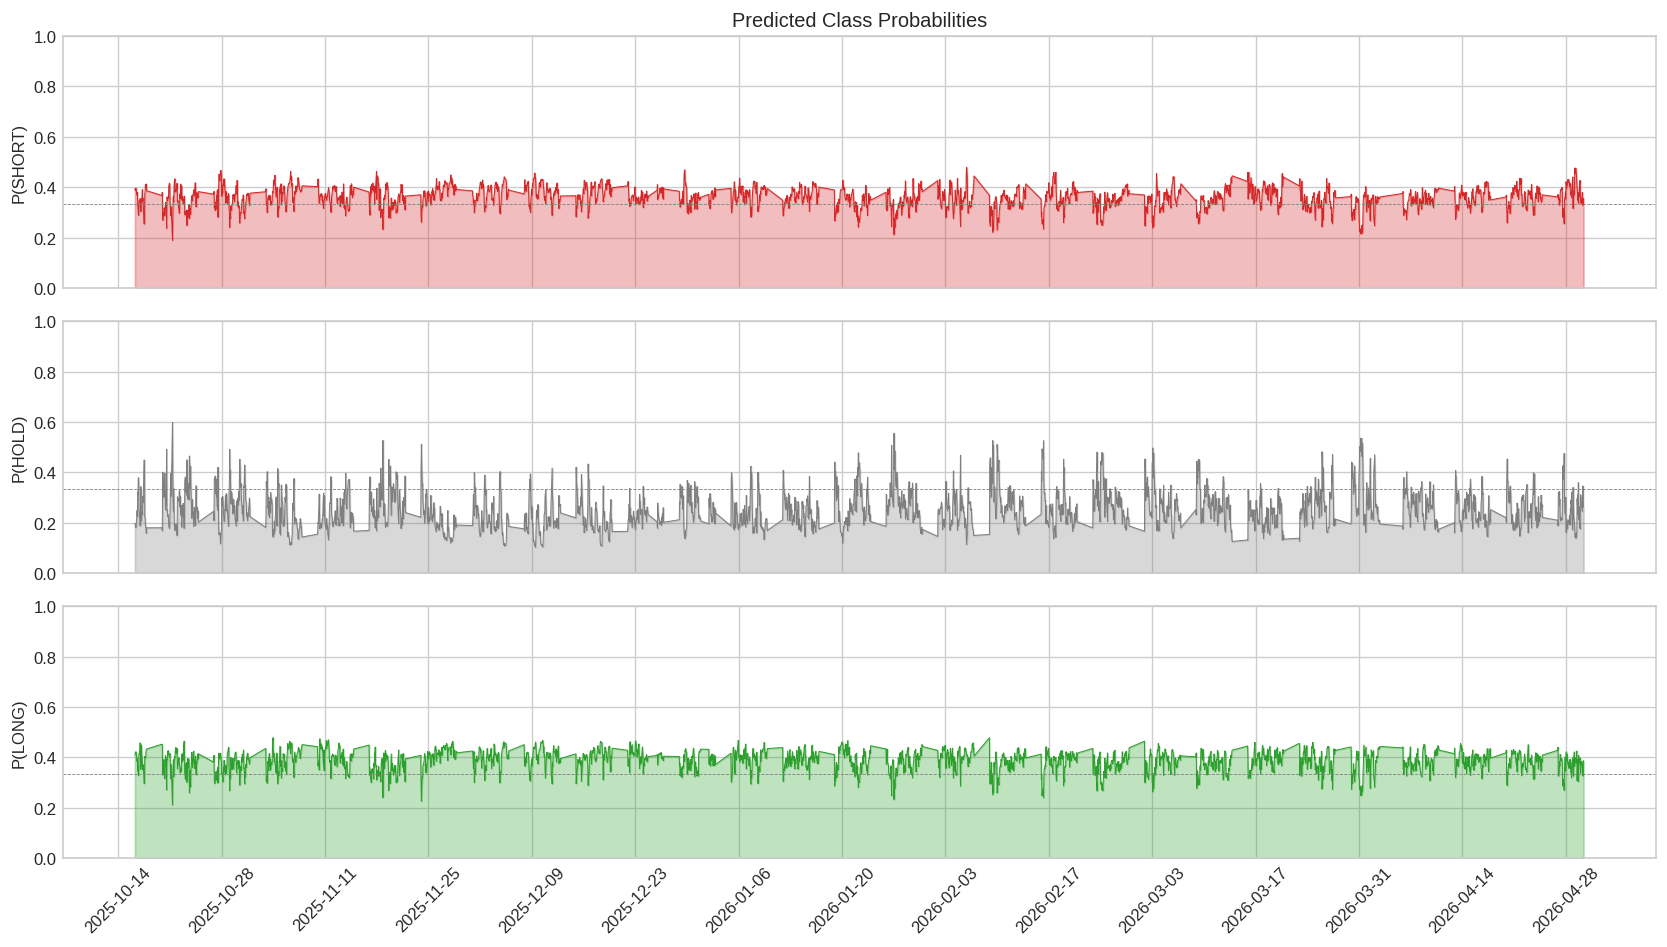

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

label_map = {0: 0, 1: 1, 2: -1}
class_labels = [-1, 0, 1]

for i, (label_val, ax) in enumerate(zip(class_labels, axes)):
    col_idx = i
    ax.plot(test.index, pred_proba[:, col_idx], color=PALETTE[label_val], linewidth=0.6)
    ax.fill_between(test.index, 0, pred_proba[:, col_idx], alpha=0.3, color=PALETTE[label_val])
    ax.axhline(1/3, color="gray", linewidth=0.5, linestyle="--")
    ax.set_ylabel(f"P({LABEL_NAMES[label_val]})")
    ax.set_ylim(0, 1)

axes[0].set_title("Predicted Class Probabilities")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()

## 11. Backtest Visualization

In [19]:
metrics = backtest_signals(test, predictions)
strategy_returns = cost_adjusted_returns(test, predictions, TradingCosts())
equity = equity_curve(strategy_returns, test.index).rename("equity")

bh_returns = test["close"].pct_change().shift(-1).fillna(0).to_numpy()
bh_equity = equity_curve(bh_returns, test.index).rename("buy_and_hold")

for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

trades: 2788.0000
total_return: -0.1610
sharpe: -0.9313
max_drawdown: -0.3018
profit_factor: 0.9600


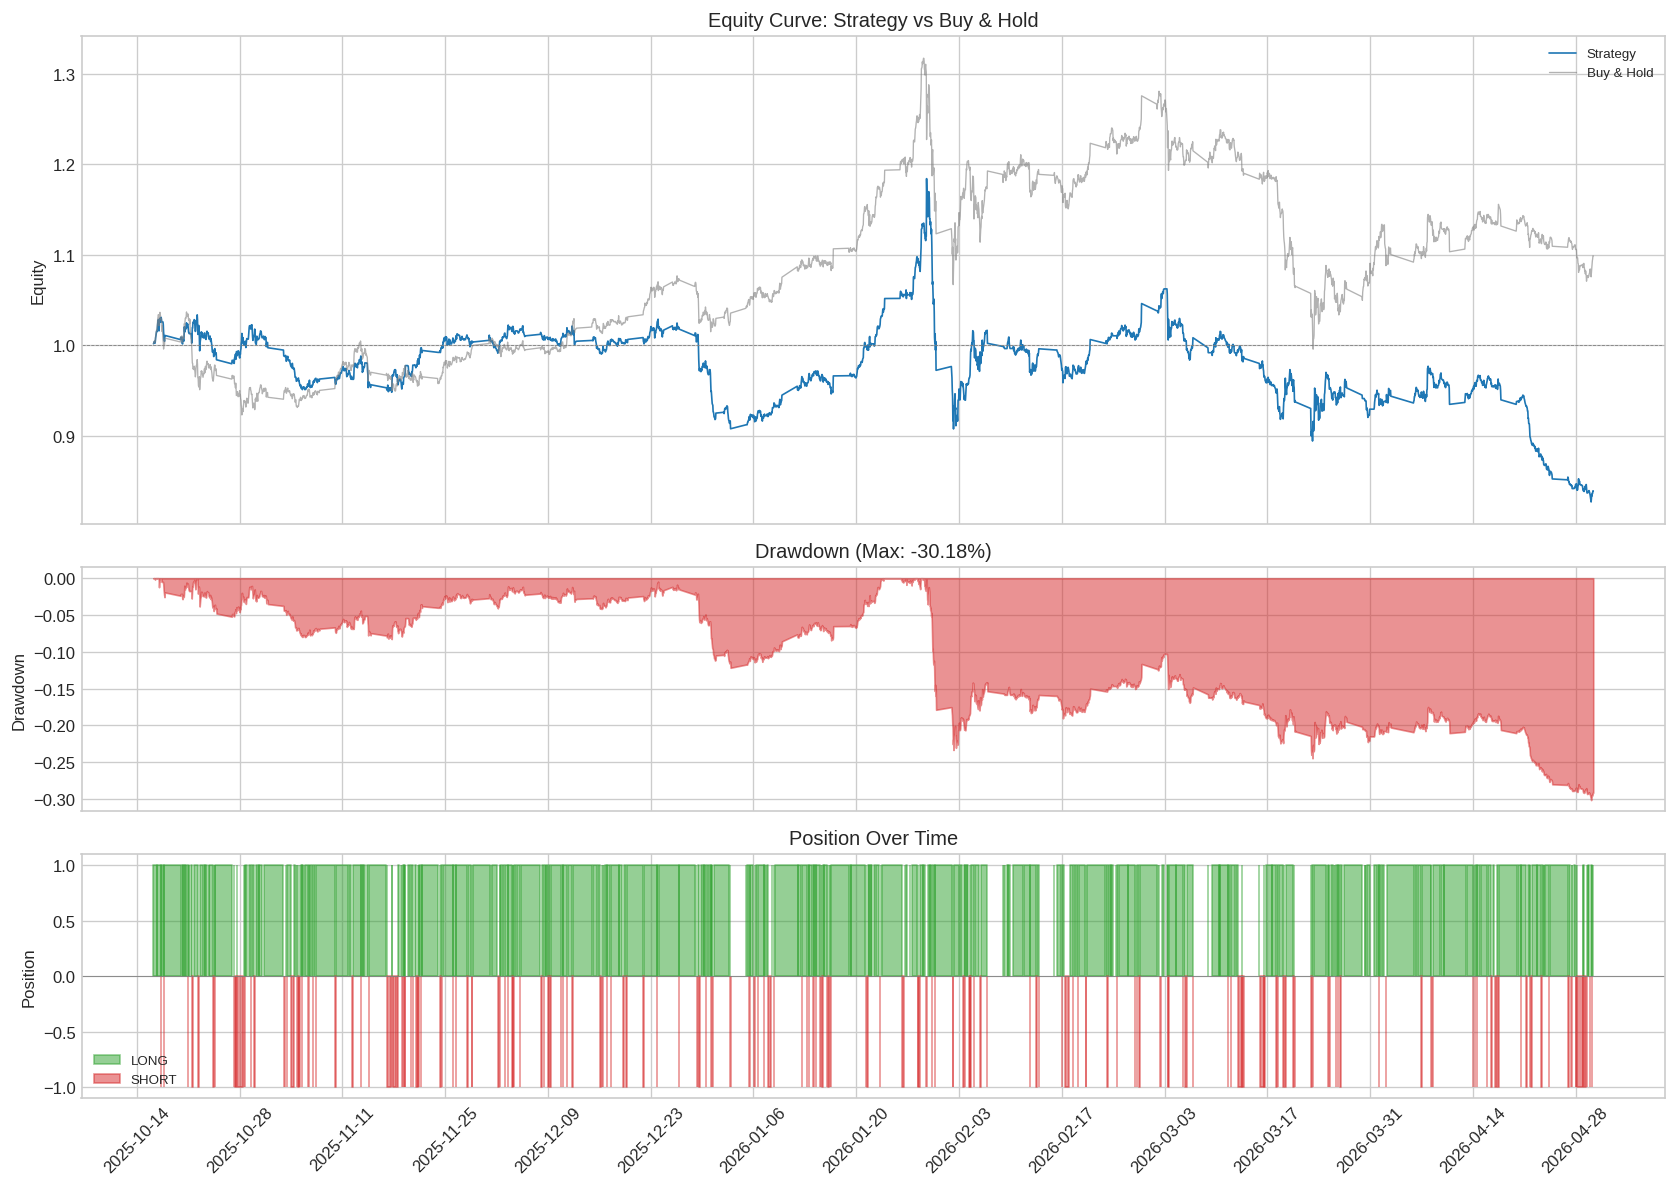

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, height_ratios=[2, 1, 1])

axes[0].plot(equity.index, equity.values, color="#1f77b4", linewidth=1, label="Strategy")
axes[0].plot(bh_equity.index, bh_equity.values, color="#7f7f7f", linewidth=0.8, alpha=0.6, label="Buy & Hold")
axes[0].axhline(1, color="gray", linewidth=0.5, linestyle="--")
axes[0].set_title("Equity Curve: Strategy vs Buy & Hold")
axes[0].set_ylabel("Equity")
axes[0].legend(fontsize=8)

drawdown = equity / equity.cummax() - 1
axes[1].fill_between(drawdown.index, 0, drawdown.values, color="#d62728", alpha=0.5)
axes[1].set_title(f"Drawdown (Max: {metrics['max_drawdown']:.2%})")
axes[1].set_ylabel("Drawdown")

pred_series = pd.Series(predictions, index=test.index)
positions = pred_series.copy()
axes[2].fill_between(positions.index, 0, positions.values, where=positions > 0, color="#2ca02c", alpha=0.5, label="LONG")
axes[2].fill_between(positions.index, 0, positions.values, where=positions < 0, color="#d62728", alpha=0.5, label="SHORT")
axes[2].axhline(0, color="gray", linewidth=0.5)
axes[2].set_title("Position Over Time")
axes[2].set_ylabel("Position")
axes[2].legend(fontsize=8)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
axes[2].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45)

fig.tight_layout()
plt.show()

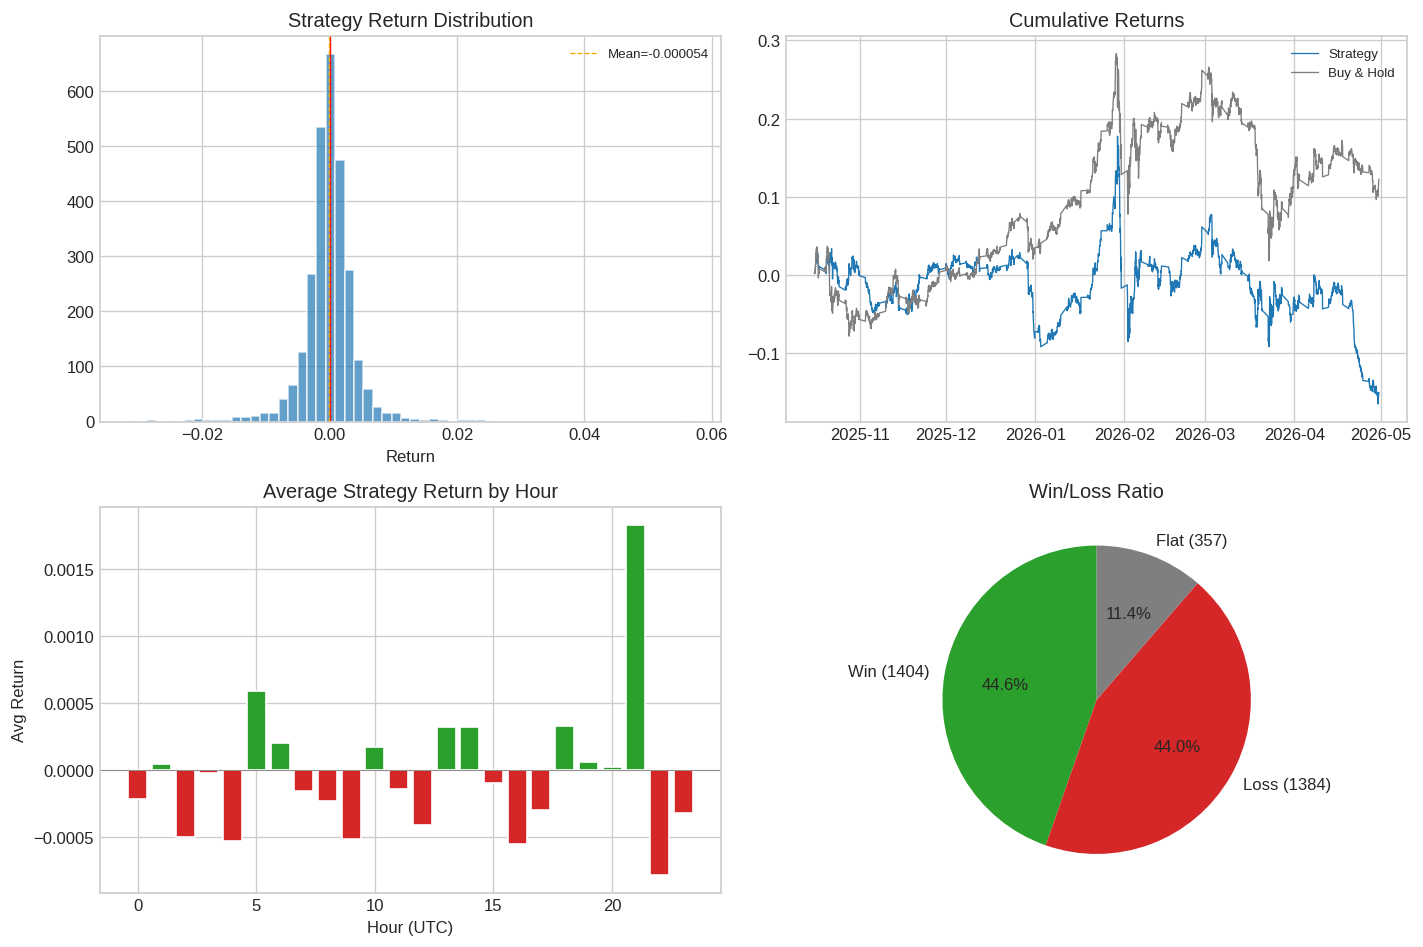

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(strategy_returns[strategy_returns != 0], bins=60, color="#1f77b4", alpha=0.7, edgecolor="white")
axes[0, 0].axvline(0, color="red", linewidth=0.8)
axes[0, 0].axvline(np.mean(strategy_returns[strategy_returns != 0]), color="orange", linewidth=0.8, linestyle="--", label=f"Mean={np.mean(strategy_returns[strategy_returns != 0]):.6f}")
axes[0, 0].set_title("Strategy Return Distribution")
axes[0, 0].set_xlabel("Return")
axes[0, 0].legend(fontsize=8)

cum_strat = np.cumsum(strategy_returns)
cum_bh = np.cumsum(bh_returns)
axes[0, 1].plot(test.index, cum_strat, color="#1f77b4", linewidth=0.8, label="Strategy")
axes[0, 1].plot(test.index, cum_bh, color="#7f7f7f", linewidth=0.8, label="Buy & Hold")
axes[0, 1].set_title("Cumulative Returns")
axes[0, 1].legend(fontsize=8)

long_mask = predictions == 1
short_mask = predictions == -1
hold_mask = predictions == 0
hourly = pd.DataFrame({"hour": test.index.hour, "return": strategy_returns})
hourly_grouped = hourly.groupby("hour")["return"].mean()
bar_colors = ["#2ca02c" if v > 0 else "#d62728" for v in hourly_grouped.values]
axes[1, 0].bar(hourly_grouped.index, hourly_grouped.values, color=bar_colors, edgecolor="white")
axes[1, 0].axhline(0, color="gray", linewidth=0.5)
axes[1, 0].set_title("Average Strategy Return by Hour")
axes[1, 0].set_xlabel("Hour (UTC)")
axes[1, 0].set_ylabel("Avg Return")

wins = (strategy_returns > 0).sum()
losses = (strategy_returns < 0).sum()
neutral = (strategy_returns == 0).sum()
axes[1, 1].pie(
    [wins, losses, neutral],
    labels=[f"Win ({wins})", f"Loss ({losses})", f"Flat ({neutral})"],
    colors=["#2ca02c", "#d62728", "#7f7f7f"],
    autopct="%.1f%%", startangle=90
)
axes[1, 1].set_title("Win/Loss Ratio")

fig.tight_layout()
plt.show()

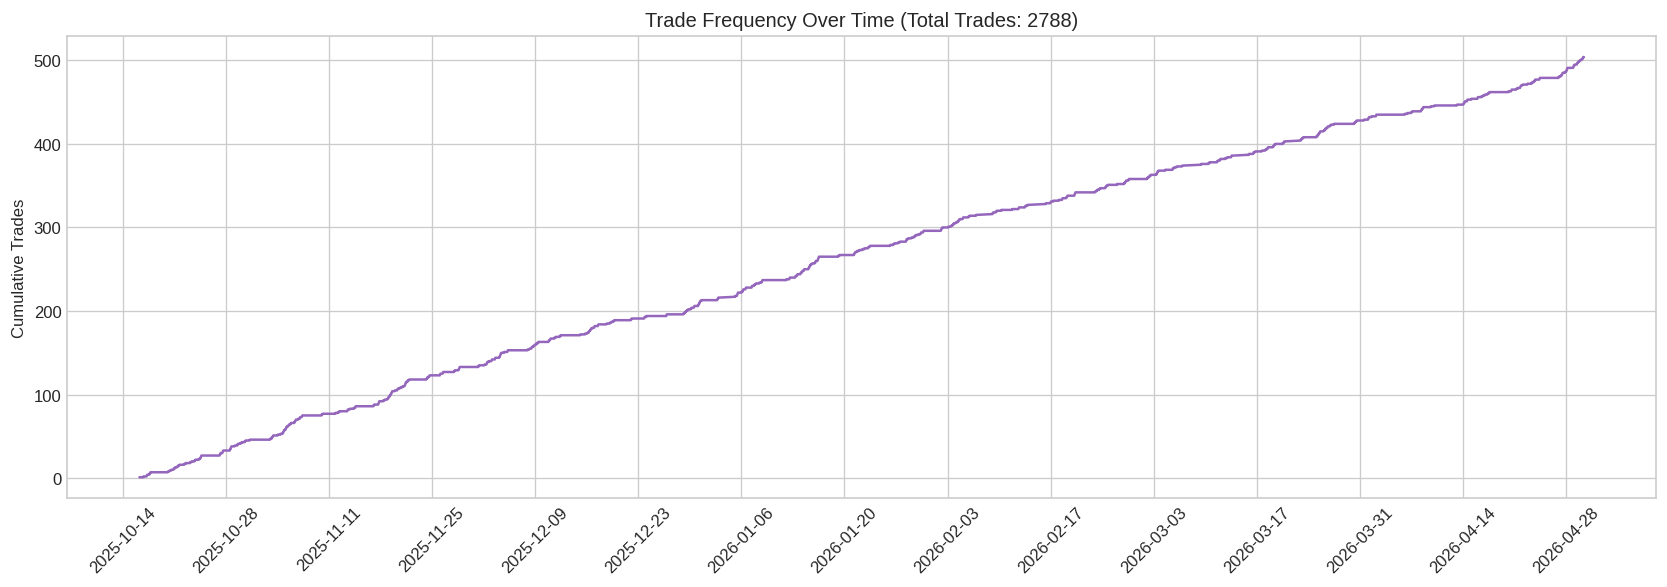

In [22]:
fig, ax = plt.subplots(figsize=(14, 5))

signal_changes = np.diff(predictions, prepend=0) != 0
trade_entry_idx = np.where((predictions != 0) & signal_changes)[0]

if len(trade_entry_idx) > 0:
    rolling_trades = pd.Series(0, index=test.index)
    rolling_trades.iloc[trade_entry_idx] = 1
    rolling_count = rolling_trades.cumsum()
    ax.plot(rolling_count.index, rolling_count.values, color="#9467bd", linewidth=1.5)
    ax.set_ylabel("Cumulative Trades")
    ax.set_title(f"Trade Frequency Over Time (Total Trades: {int(metrics['trades'])})")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.xticks(rotation=45)
else:
    ax.text(0.5, 0.5, "No trades", transform=ax.transAxes, ha="center")

fig.tight_layout()
plt.show()

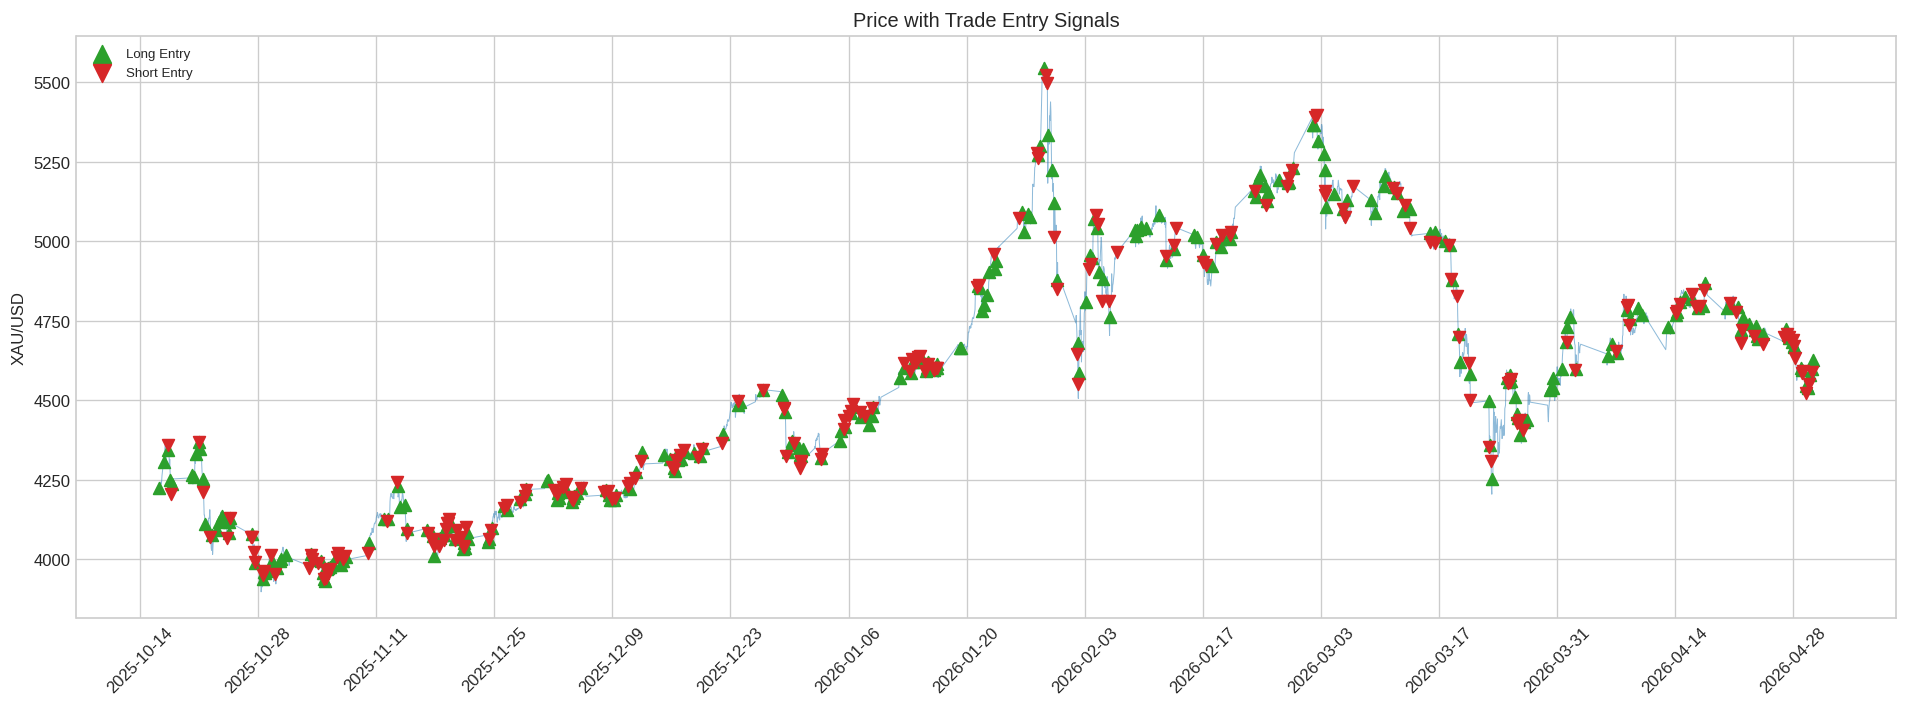

In [23]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(test.index, test["close"], color="#1f77b4", linewidth=0.6, alpha=0.5)

long_entries = (predictions == 1) & np.r_[True, predictions[:-1] != 1]
short_entries = (predictions == -1) & np.r_[True, predictions[:-1] != -1]

ax.scatter(test.index[long_entries], test["close"].iloc[long_entries],
            marker="^", c="#2ca02c", s=50, zorder=5, label="Long Entry")
ax.scatter(test.index[short_entries], test["close"].iloc[short_entries],
            marker="v", c="#d62728", s=50, zorder=5, label="Short Entry")

ax.set_title("Price with Trade Entry Signals")
ax.set_ylabel("XAU/USD")
ax.legend(loc="upper left", fontsize=8, markerscale=1.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()

## 12. Rolling Performance Metrics

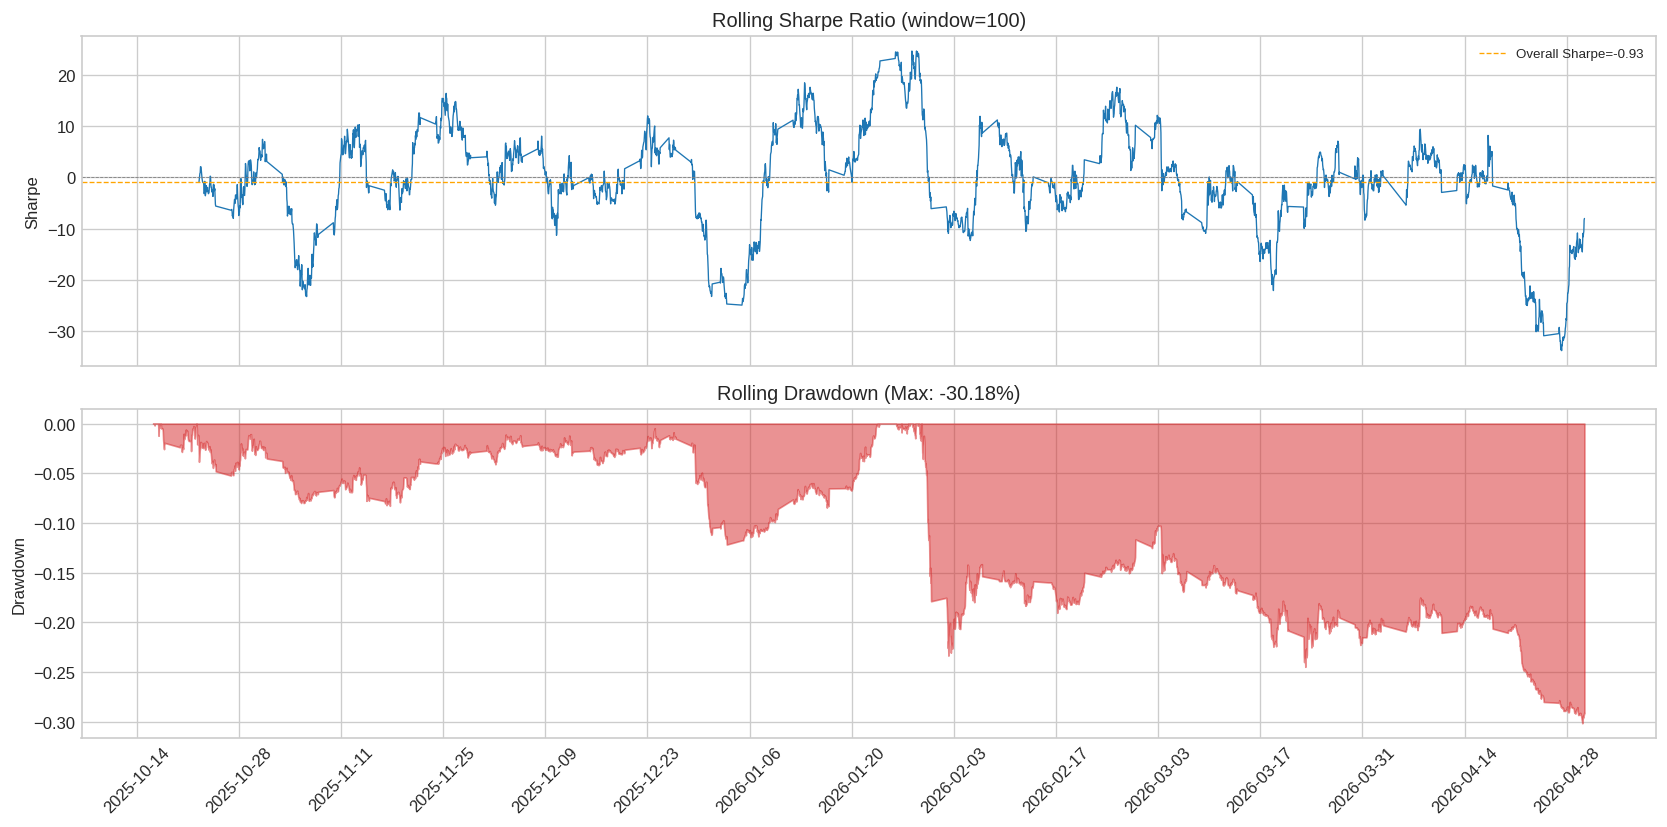

In [24]:
window = min(100, len(strategy_returns) // 3)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

rolling_sharpe = pd.Series(strategy_returns).rolling(window).apply(
    lambda x: np.sqrt(24 * 252) * x.mean() / x.std() if x.std() > 0 else 0, raw=True
)
axes[0].plot(test.index, rolling_sharpe.values, color="#1f77b4", linewidth=0.8)
axes[0].axhline(0, color="gray", linewidth=0.5, linestyle="--")
axes[0].axhline(metrics["sharpe"], color="orange", linewidth=0.8, linestyle="--", label=f"Overall Sharpe={metrics['sharpe']:.2f}")
axes[0].set_title(f"Rolling Sharpe Ratio (window={window})")
axes[0].set_ylabel("Sharpe")
axes[0].legend(fontsize=8)

rolling_eq = pd.Series(equity.values)
rolling_dd = rolling_eq / rolling_eq.cummax() - 1
axes[1].fill_between(test.index, 0, rolling_dd.values, color="#d62728", alpha=0.5)
axes[1].set_title(f"Rolling Drawdown (Max: {metrics['max_drawdown']:.2%})")
axes[1].set_ylabel("Drawdown")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45)

fig.tight_layout()
plt.show()

## 13. Summary Dashboard

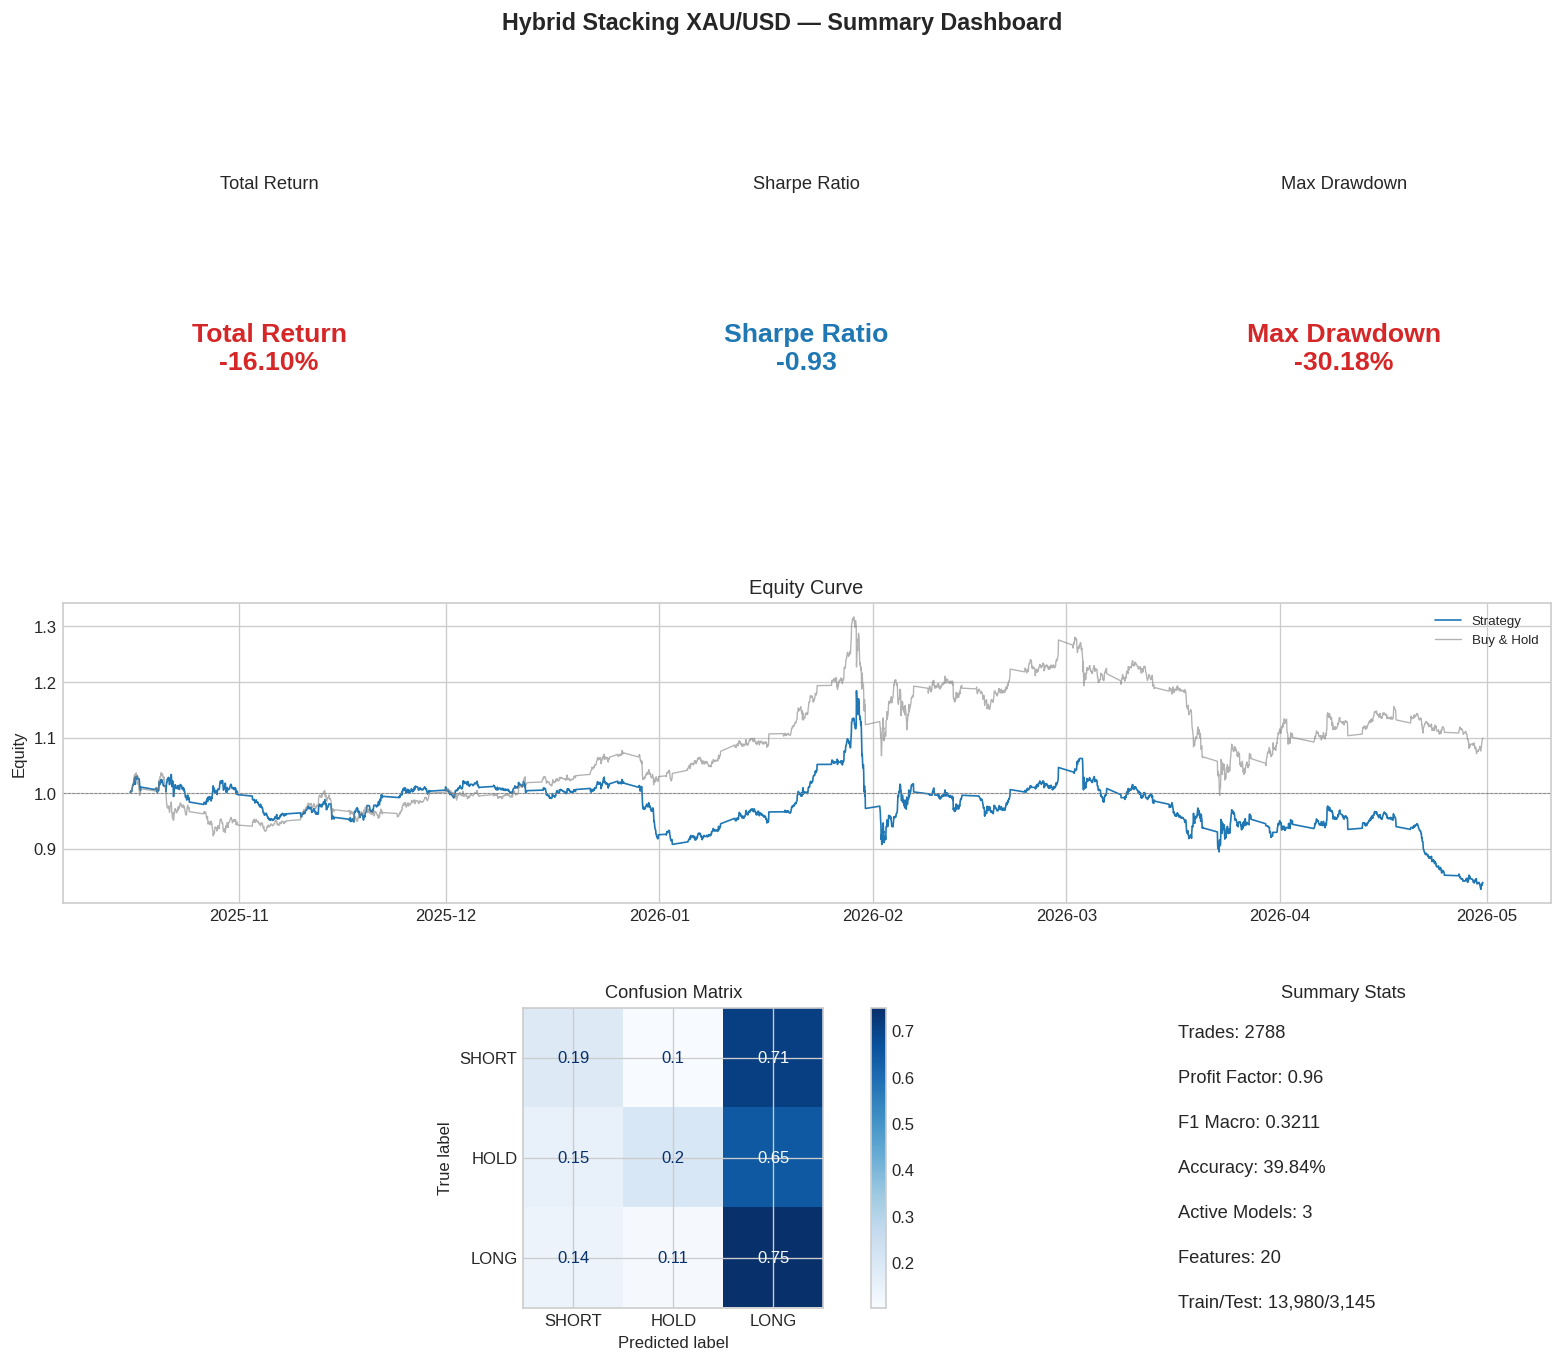

In [25]:
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.35, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
ax1.text(0.5, 0.5, f"Total Return\n{metrics['total_return']:.2%}",
         ha="center", va="center", fontsize=16, fontweight="bold",
         color="#2ca02c" if metrics["total_return"] > 0 else "#d62728",
         transform=ax1.transAxes)
ax1.set_title("Total Return", fontsize=11)
ax1.axis("off")

ax2 = fig.add_subplot(gs[0, 1])
ax2.text(0.5, 0.5, f"Sharpe Ratio\n{metrics['sharpe']:.2f}",
         ha="center", va="center", fontsize=16, fontweight="bold",
         color="#1f77b4", transform=ax2.transAxes)
ax2.set_title("Sharpe Ratio", fontsize=11)
ax2.axis("off")

ax3 = fig.add_subplot(gs[0, 2])
ax3.text(0.5, 0.5, f"Max Drawdown\n{metrics['max_drawdown']:.2%}",
         ha="center", va="center", fontsize=16, fontweight="bold",
         color="#d62728", transform=ax3.transAxes)
ax3.set_title("Max Drawdown", fontsize=11)
ax3.axis("off")

ax4 = fig.add_subplot(gs[1, :])
ax4.plot(equity.index, equity.values, color="#1f77b4", linewidth=1, label="Strategy")
ax4.plot(bh_equity.index, bh_equity.values, color="#7f7f7f", linewidth=0.8, alpha=0.6, label="Buy & Hold")
ax4.axhline(1, color="gray", linewidth=0.5, linestyle="--")
ax4.set_title("Equity Curve")
ax4.legend(fontsize=8)
ax4.set_ylabel("Equity")

ax5 = fig.add_subplot(gs[2, :2])
ConfusionMatrixDisplay.from_predictions(
    test["label"], predictions,
    display_labels=[LABEL_NAMES[k] for k in sorted(LABEL_NAMES)],
    cmap="Blues", ax=ax5, normalize="true",
)
ax5.set_title("Confusion Matrix", fontsize=11)

ax6 = fig.add_subplot(gs[2, 2])
ax6.text(0.1, 0.9, f"Trades: {int(metrics['trades'])}", transform=ax6.transAxes, fontsize=11)
ax6.text(0.1, 0.75, f"Profit Factor: {metrics['profit_factor']:.2f}", transform=ax6.transAxes, fontsize=11)
ax6.text(0.1, 0.6, f"F1 Macro: {f1_score(test['label'], predictions, average='macro', zero_division=0):.4f}", transform=ax6.transAxes, fontsize=11)
ax6.text(0.1, 0.45, f"Accuracy: {accuracy_score(test['label'], predictions):.2%}", transform=ax6.transAxes, fontsize=11)
ax6.text(0.1, 0.3, f"Active Models: {len(model.active_model_names_)}", transform=ax6.transAxes, fontsize=11)
ax6.text(0.1, 0.15, f"Features: {len(features)}", transform=ax6.transAxes, fontsize=11)
ax6.text(0.1, 0.0, f"Train/Test: {len(train):,}/{len(test):,}", transform=ax6.transAxes, fontsize=11)
ax6.set_title("Summary Stats", fontsize=11)
ax6.axis("off")

fig.suptitle("Hybrid Stacking XAU/USD — Summary Dashboard", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

## 14. Export

In [26]:
from datetime import datetime, timezone
import json

run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
run_dir = REPORT_DIR / f"run_{run_id}"
run_dir.mkdir(parents=True, exist_ok=True)

results = test[["close", "spread", "label"]].copy()
results["prediction"] = predictions
results["strategy_return"] = strategy_returns
results["equity"] = equity
results.to_csv(run_dir / "predictions.csv")
pd.Series(metrics).to_csv(run_dir / "backtest_metrics.csv")

for fig_num in plt.get_fignums():
    fig = plt.figure(fig_num)
    fig.savefig(run_dir / f"plot_{fig_num:02d}.png", dpi=160, bbox_inches="tight")

run_data = {
    "run_id": run_id,
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "config": {
        "months": MONTHS,
        "cv_splits": CV_SPLITS,
        "embargo_pct": EMBARGO_PCT,
        "purge_pct": PURGE_PCT,
        "fractional_d": FRACTIONAL_D,
        "min_oof_f1": MIN_OOF_F1,
        "random_state": RANDOM_STATE,
        "timeframe": "1h",
        "trading_costs": {
            "slippage_points": TradingCosts().slippage_points,
            "spread_multiplier": TradingCosts().spread_multiplier,
        },
    },
    "dataset": {
        "total_rows": len(dataset),
        "train_rows": len(train),
        "test_rows": len(test),
        "feature_count": len(features),
        "features": features,
        "fractional_d": dataset.attrs.get("fractional_d"),
        "data_range": {
            "start": str(dataset.index[0]),
            "end": str(dataset.index[-1]),
        },
        "train_range": {
            "start": str(train.index[0]),
            "end": str(train.index[-1]),
        },
        "test_range": {
            "start": str(test.index[0]),
            "end": str(test.index[-1]),
        },
        "label_distribution": dataset["label"].value_counts().sort_index().to_dict(),
    },
    "training": {
        "oof_scores": {k: round(v, 6) for k, v in model.oof_scores_.items()},
        "active_models": model.active_model_names_,
        "filtered_models": [n for n in model.oof_scores_ if n not in model.active_model_names_],
    },
    "evaluation": {
        "accuracy": round(float(accuracy_score(test["label"], predictions)), 6),
        "f1_macro": round(float(f1_score(test["label"], predictions, average="macro", zero_division=0)), 6),
        "classification_report": classification_report(test["label"], predictions, zero_division=0, output_dict=True),
    },
    "backtest": {k: round(float(v), 6) for k, v in metrics.items()},
}

with open(run_dir / "run_data.json", "w", encoding="utf-8") as f:
    json.dump(run_data, f, indent=2, ensure_ascii=False, default=str)

print(f"Run ID: {run_id}")
print(f"Exported to {run_dir.resolve()}")
print(f"Files: predictions.csv, backtest_metrics.csv, run_data.json, plot_*.png")

Run ID: 20260521_231601
Exported to /home/ultimatebrok/Downloads/thesis-compact/reports/run_20260521_231601
Files: predictions.csv, backtest_metrics.csv, run_data.json, plot_*.png
